# Problem 5: Implementing SVMs from Scratch — Hinge vs. Logistic Loss

**Dataset:** HTRU2 — Predicting a Pulsar Star  
**Tools:** NumPy (all model fitting), pandas (I/O), matplotlib/seaborn (plots)  
**Constraint:** No `sklearn.svm` permitted

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
sns.set_style('whitegrid')

---
## Part (a): EDA and Preprocessing

### (a)(i) Shape and Class Balance

In [2]:
# Load dataset
df = pd.read_csv('HW_2_Datasets/HW_2_Datasets/HW_5/pulsar_data_train.csv')
df.columns = df.columns.str.strip()  # Remove leading/trailing whitespace from column names

# Rename columns to concise identifiers
col_map = {
    'Mean of the integrated profile':               'Mean_Integrated',
    'Standard deviation of the integrated profile': 'SD_Integrated',
    'Excess kurtosis of the integrated profile':    'EK_Integrated',
    'Skewness of the integrated profile':           'Skewness_Integrated',
    'Mean of the DM-SNR curve':                     'Mean_DMSNR',
    'Standard deviation of the DM-SNR curve':       'SD_DMSNR',
    'Excess kurtosis of the DM-SNR curve':          'EK_DMSNR',
    'Skewness of the DM-SNR curve':                 'Skewness_DMSNR',
}
df.rename(columns=col_map, inplace=True)

FEATURE_COLS = list(col_map.values())
TARGET_COL   = 'target_class'

# Drop rows with any missing values
n_before = len(df)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows before drop: {n_before}  |  After drop: {len(df)}  |  Dropped: {n_before - len(df)}')
print(f'Shape: {df.shape}\n')

display(df.describe())

pulsar_frac = df[TARGET_COL].mean()
print(f'\nFraction with target_class = 1 (pulsar): {pulsar_frac:.4f}  ({100*pulsar_frac:.2f}%)')
print(f'Trivial "always predict 0" accuracy: {100*(1-pulsar_frac):.2f}%')
print('''
Why accuracy alone is misleading:
  The dataset is heavily class-imbalanced (~90% non-pulsar, ~10% pulsar).
  A trivial classifier that always outputs class 0 achieves ~90% accuracy
  without learning anything useful about pulsars. Metrics like precision,
  recall, F1, or AUC-PR better capture performance on the rare positive class.
''')

Rows before drop: 12528  |  After drop: 9273  |  Dropped: 3255
Shape: (9273, 9)



,Mean_Integrated,SD_Integrated,EK_Integrated,Skewness_Integrated,Mean_DMSNR,SD_DMSNR,EK_DMSNR,Skewness_DMSNR,target_class
count,9273.000000,9273.000000,9273.000000,9273.000000,9273.000000,9273.000000,9273.000000,9273.000000,9273.000000
mean,111.133750,46.514053,0.479546,1.790673,12.735359,26.327860,8.327933,105.783345,0.091664
std,25.686405,6.781320,1.071155,6.286567,29.766782,19.542634,4.549914,108.166669,0.288567
min,6.187500,24.772042,-1.738021,-1.791886,0.213211,7.370432,-2.636857,-1.976976,0.000000
25%,100.984375,42.398382,0.024497,-0.188021,1.910535,14.376641,5.788817,34.917943,0.000000
50%,115.234375,46.895026,0.223858,0.202884,2.797659,18.435186,8.427475,83.151969,0.000000
75%,127.328125,51.001785,0.472066,0.930710,5.459866,28.387019,10.721934,139.770330,0.000000
max,189.734375,91.808628,8.069522,68.101622,211.948997,110.642211,34.539844,1191.000837,1.000000



Fraction with target_class = 1 (pulsar): 0.0917  (9.17%)
Trivial "always predict 0" accuracy: 90.83%

Why accuracy alone is misleading:
  The dataset is heavily class-imbalanced (~90% non-pulsar, ~10% pulsar).
  A trivial classifier that always outputs class 0 achieves ~90% accuracy
  without learning anything useful about pulsars. Metrics like precision,
  recall, F1, or AUC-PR better capture performance on the rare positive class.



### (a)(ii) Feature Distributions by Class

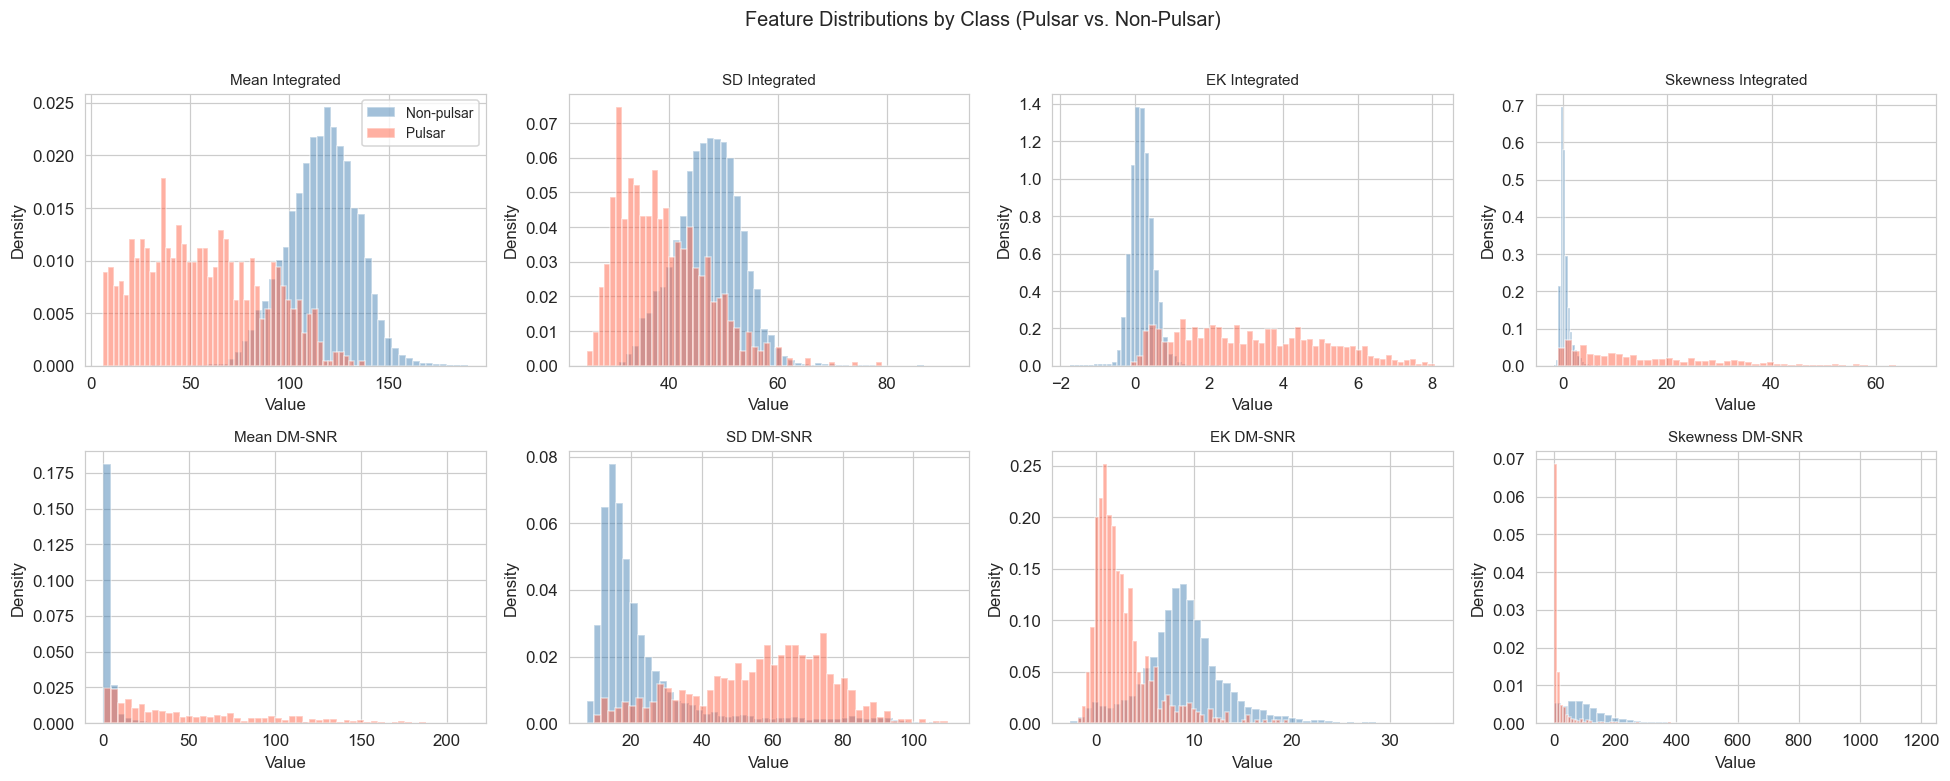


Observations:
  Best-separating features (clear bimodal or shift): Mean_Integrated, SD_Integrated,
  Mean_DMSNR, SD_DMSNR. Pulsars tend to have lower Mean_Integrated and lower Mean_DMSNR.

  Relation to margin intuition (Problem 1.3):
  Features that separate classes well produce large |m_n| = |y_n(w^T x_n + b)| once
  the model is trained, because the decision hyperplane can achieve a large margin.
  Features with heavily overlapping distributions (EK_Integrated, Skewness_Integrated)
  will contribute less discriminative power and produce smaller per-example margins.



In [3]:
pulsars     = df[df[TARGET_COL] == 1]
non_pulsars = df[df[TARGET_COL] == 0]

feature_labels = [
    'Mean Integrated', 'SD Integrated', 'EK Integrated', 'Skewness Integrated',
    'Mean DM-SNR',     'SD DM-SNR',     'EK DM-SNR',     'Skewness DM-SNR'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(FEATURE_COLS, feature_labels)):
    ax = axes[i]
    ax.hist(non_pulsars[col].dropna(), bins=50, alpha=0.5,
            color='steelblue', label='Non-pulsar', density=True)
    ax.hist(pulsars[col].dropna(), bins=50, alpha=0.5,
            color='tomato', label='Pulsar', density=True)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Feature Distributions by Class (Pulsar vs. Non-Pulsar)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('''
Observations:
  Best-separating features (clear bimodal or shift): Mean_Integrated, SD_Integrated,
  Mean_DMSNR, SD_DMSNR. Pulsars tend to have lower Mean_Integrated and lower Mean_DMSNR.

  Relation to margin intuition (Problem 1.3):
  Features that separate classes well produce large |m_n| = |y_n(w^T x_n + b)| once
  the model is trained, because the decision hyperplane can achieve a large margin.
  Features with heavily overlapping distributions (EK_Integrated, Skewness_Integrated)
  will contribute less discriminative power and produce smaller per-example margins.
''')

### (a)(iii) Preprocessing

In [4]:
# Convert labels: 0 -> -1, 1 -> +1  (SVM convention from Problem 1)
X_all = df[FEATURE_COLS].values.astype(float)
y_all = np.where(df[TARGET_COL].values == 1, 1.0, -1.0)

N = len(X_all)
print(f'Total samples: {N}')

# 60 / 20 / 20 split
np.random.seed(42)
idx      = np.random.permutation(N)
n_train  = int(0.60 * N)
n_val    = int(0.20 * N)
# n_test = N - n_train - n_val (remainder)

train_idx = idx[:n_train]
val_idx   = idx[n_train : n_train + n_val]
test_idx  = idx[n_train + n_val :]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val,   y_val   = X_all[val_idx],   y_all[val_idx]
X_test,  y_test  = X_all[test_idx],  y_all[test_idx]

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')
print(f'Train pulsar rate: {(y_train==1).mean():.3f}  |  '
      f'Val: {(y_val==1).mean():.3f}  |  Test: {(y_test==1).mean():.3f}')

# Standardize using training-set statistics ONLY
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_s = (X_train - mu) / sigma
X_val_s   = (X_val   - mu) / sigma
X_test_s  = (X_test  - mu) / sigma

print('\nConvention: w (shape d,) and b (scalar) are kept SEPARATE throughout.')
print('Labels are y in {-1, +1} (SVM convention).')
print('\nWhy not standardize on combined train+test?')
print('  Using test-set statistics during preprocessing leaks information about the test')
print('  distribution into training. This inflates estimated generalisation performance')
print('  (data leakage). mu and sigma must be computed on training data only, then')
print('  applied to val and test as fixed transformations.')

Total samples: 9273
Train: (5563, 8)  |  Val: (1854, 8)  |  Test: (1856, 8)
Train pulsar rate: 0.091  |  Val: 0.092  |  Test: 0.093

Convention: w (shape d,) and b (scalar) are kept SEPARATE throughout.
Labels are y in {-1, +1} (SVM convention).

Why not standardize on combined train+test?
  Using test-set statistics during preprocessing leaks information about the test
  distribution into training. This inflates estimated generalisation performance
  (data leakage). mu and sigma must be computed on training data only, then
  applied to val and test as fixed transformations.


---
## Part (b): Hinge-Loss SVM via Subgradient Descent

### (b)(i) Gradient Formula

For a single example $(x, y)$ with margin $m = y(w^T x + b)$:
$$\partial_w \ell_{\text{hinge}} = -y\,x \cdot \mathbf{1}[m < 1], \qquad \partial_b \ell_{\text{hinge}} = -y \cdot \mathbf{1}[m < 1]$$

Full objective (mean-normalized for numerical stability with $\eta = 10^{-3}$):
$$J_{\text{hinge}}(w, b) = \frac{1}{N}\sum_{n=1}^N \max(0, 1 - m_n) + \frac{\lambda}{2}\|w\|^2$$

Subgradient of the full objective:
$$\nabla_w J_{\text{hinge}} = \frac{1}{N}\sum_{n=1}^N -y_n x_n \cdot \mathbf{1}[m_n < 1] + \lambda w,
\qquad
\frac{\partial J_{\text{hinge}}}{\partial b} = \frac{1}{N}\sum_{n=1}^N -y_n \cdot \mathbf{1}[m_n < 1]$$

*(The $\frac{1}{N}$ normalisation makes the magnitude of the gradient independent of dataset size, so the same $\eta = 10^{-3}$ is sensible.)*

### (b)(ii) Implementation and Training

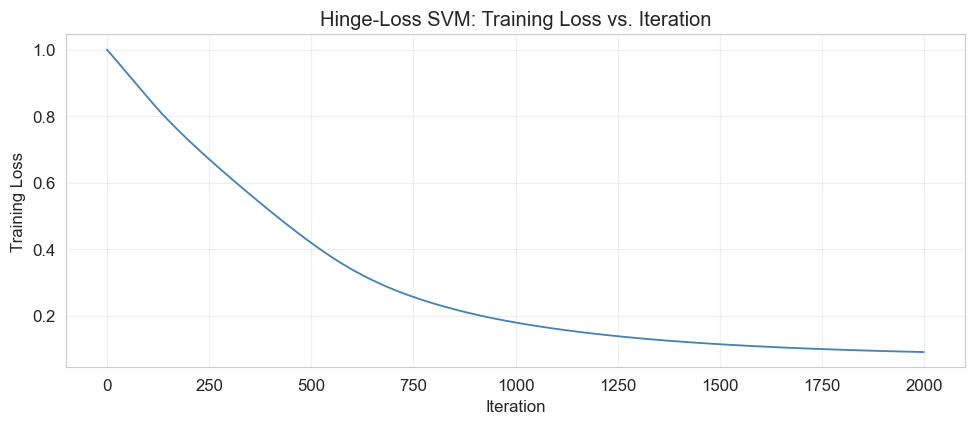

Is the loss monotonically decreasing?
  Monotone: True

Subgradient descent is NOT guaranteed to decrease the objective at every step.
Unlike a true gradient, a subgradient at a non-differentiable point (m=1) is not
necessarily a descent direction, so individual steps can increase the loss. In practice
the loss trend is downward but with local oscillations near the kink at m=1.



In [5]:
def train_hinge_svm(X, y, lam=1e-3, eta=1e-3, n_iter=2000):
    """
    Full-batch subgradient descent for the hinge-loss SVM.
    Objective: J = (1/N)*sum_n max(0,1-m_n) + (lam/2)*||w||^2
    Returns: w, b, loss history
    """
    N, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = np.empty(n_iter)

    for t in range(n_iter):
        margins = y * (X @ w + b)                         # (N,)
        hinge   = np.maximum(0.0, 1.0 - margins)          # per-example loss
        losses[t] = hinge.mean() + 0.5 * lam * np.dot(w, w)

        active = (margins < 1.0).astype(float)            # 1 where subgradient is non-zero
        grad_w = -(active * y) @ X / N + lam * w
        grad_b = -(active * y).sum() / N

        w -= eta * grad_w
        b -= eta * grad_b

    return w, b, losses


LAM    = 1e-3
ETA    = 1e-3
N_ITER = 2000

w_hinge, b_hinge, losses_hinge = train_hinge_svm(
    X_train_s, y_train, lam=LAM, eta=ETA, n_iter=N_ITER
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(losses_hinge, color='steelblue', linewidth=1.2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Training Loss')
ax.set_title('Hinge-Loss SVM: Training Loss vs. Iteration')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Is the loss monotonically decreasing?')
mono = np.all(np.diff(losses_hinge) <= 1e-12)
print(f'  Monotone: {mono}')
print('''
Subgradient descent is NOT guaranteed to decrease the objective at every step.
Unlike a true gradient, a subgradient at a non-differentiable point (m=1) is not
necessarily a descent direction, so individual steps can increase the loss. In practice
the loss trend is downward but with local oscillations near the kink at m=1.
''')

### (b)(iii) Who Is Actually Contributing?

In [6]:
def accuracy(X, y, w, b):
    return np.mean(np.sign(X @ w + b) == y)

train_acc_hinge = accuracy(X_train_s, y_train, w_hinge, b_hinge)
val_acc_hinge   = accuracy(X_val_s,   y_val,   w_hinge, b_hinge)
print(f'Hinge SVM  |  Train acc: {train_acc_hinge:.4f}  |  Val acc: {val_acc_hinge:.4f}')

# Margins on training set
margins_hinge_train = y_train * (X_train_s @ w_hinge + b_hinge)

# m_n >= 1  <=>  zero subgradient
zero_mask = margins_hinge_train >= 1.0
n_zero_total  = zero_mask.sum()
n_zero_pulsar = (zero_mask & (y_train == 1)).sum()
n_zero_nonp   = (zero_mask & (y_train == -1)).sum()

active_mask   = ~zero_mask
n_act_total   = active_mask.sum()
n_act_pulsar  = (active_mask & (y_train == 1)).sum()
n_act_nonp    = (active_mask & (y_train == -1)).sum()

N_tr = len(y_train)
print(f'\nTraining set size: {N_tr}')
print(f'  Pulsars (y=+1): {(y_train==1).sum()}  |  Non-pulsars (y=-1): {(y_train==-1).sum()}')
print(f'\nExamples with m_n >= 1 (zero subgradient): {n_zero_total} / {N_tr}  ({100*n_zero_total/N_tr:.1f}%)')
print(f'  Breakdown  |  Non-pulsars: {n_zero_nonp}  |  Pulsars: {n_zero_pulsar}')
print(f'\nActive examples (pulling on the boundary): {n_act_total} / {N_tr}  ({100*n_act_total/N_tr:.1f}%)')
print(f'  Breakdown  |  Non-pulsars: {n_act_nonp}  |  Pulsars: {n_act_pulsar}')

n_pulsars_tr  = (y_train ==  1).sum()
n_nonpuls_tr  = (y_train == -1).sum()
print(f'\nActive rate by class:')
print(f'  Pulsars:     {n_act_pulsar}/{n_pulsars_tr} = {100*n_act_pulsar/n_pulsars_tr:.1f}%')
print(f'  Non-pulsars: {n_act_nonp}/{n_nonpuls_tr} = {100*n_act_nonp/n_nonpuls_tr:.1f}%')
print('''
Interpretation:
  Most of the absolute active count sits in the majority class (non-pulsars) simply
  because it is far larger. However, the per-class active RATE for pulsars may be
  higher, meaning that proportionally more pulsars are still inside the margin and
  pulling on the boundary. This makes sense: pulsars are rarer, the model has seen
  fewer of them, so they are harder to push outside the margin.
''')

Hinge SVM  |  Train acc: 0.9700  |  Val acc: 0.9682

Training set size: 5563
  Pulsars (y=+1): 506  |  Non-pulsars (y=-1): 5057

Examples with m_n >= 1 (zero subgradient): 4270 / 5563  (76.8%)
  Breakdown  |  Non-pulsars: 4045  |  Pulsars: 225

Active examples (pulling on the boundary): 1293 / 5563  (23.2%)
  Breakdown  |  Non-pulsars: 1012  |  Pulsars: 281

Active rate by class:
  Pulsars:     281/506 = 55.5%
  Non-pulsars: 1012/5057 = 20.0%

Interpretation:
  Most of the absolute active count sits in the majority class (non-pulsars) simply
  because it is far larger. However, the per-class active RATE for pulsars may be
  higher, meaning that proportionally more pulsars are still inside the margin and
  pulling on the boundary. This makes sense: pulsars are rarer, the model has seen
  fewer of them, so they are harder to push outside the margin.



---
## Part (c): Logistic-Loss SVM

### (c)(i) Gradient Formula

For a single example $(x, y)$ with margin $m = y(w^T x + b)$, using $\sigma(z) = 1/(1+e^{-z})$:
$$\nabla_w \ell_{\log} = -\sigma(-m)\,y\,x, \qquad \frac{\partial \ell_{\log}}{\partial b} = -\sigma(-m)\,y$$

Full mean-normalised objective:
$$J_{\log}(w, b) = \frac{1}{N}\sum_{n=1}^N \log(1 + e^{-m_n}) + \frac{\lambda}{2}\|w\|^2$$

Gradient of full objective:
$$\nabla_w J_{\log} = \frac{1}{N}\sum_{n=1}^N -\sigma(-m_n)\,y_n\,x_n + \lambda w,
\qquad
\frac{\partial J_{\log}}{\partial b} = \frac{1}{N}\sum_{n=1}^N -\sigma(-m_n)\,y_n$$

### (c)(ii) Implementation and Training

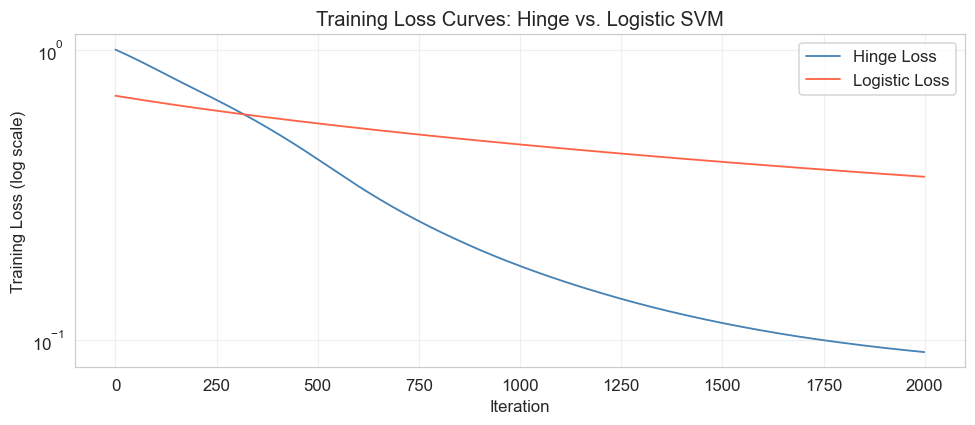


Convergence comparison:
  Logistic loss converges more smoothly because it is everywhere differentiable;
  gradient descent always has a valid, consistent descent direction. The hinge loss
  has a non-differentiable kink at m=1, so subgradient steps can occasionally
  overshoot, causing oscillations visible as a noisier loss curve.
  At eta=1e-3 both converge within 2000 iterations on this dataset.



In [7]:
def stable_sigmoid(z):
    """Numerically stable sigmoid: avoids overflow for large |z|."""
    return np.where(
        z >= 0,
        1.0 / (1.0 + np.exp(-z)),
        np.exp(z) / (1.0 + np.exp(z))
    )


def train_logistic_svm(X, y, lam=1e-3, eta=1e-3, n_iter=2000):
    """
    Full-batch gradient descent for the logistic-loss SVM.
    Objective: J = (1/N)*sum_n logaddexp(0, -m_n) + (lam/2)*||w||^2
    Uses np.logaddexp(0, -m) for numerically stable log(1 + exp(-m)).
    Returns: w, b, loss history
    """
    N, d = X.shape
    w = np.zeros(d)
    b = 0.0
    losses = np.empty(n_iter)

    for t in range(n_iter):
        margins   = y * (X @ w + b)                        # (N,)
        losses[t] = np.logaddexp(0.0, -margins).mean() + 0.5 * lam * np.dot(w, w)

        sig_neg_m = stable_sigmoid(-margins)               # sigma(-m_n)
        grad_w    = -(sig_neg_m * y) @ X / N + lam * w
        grad_b    = -(sig_neg_m * y).sum() / N

        w -= eta * grad_w
        b -= eta * grad_b

    return w, b, losses


w_log, b_log, losses_log = train_logistic_svm(
    X_train_s, y_train, lam=LAM, eta=ETA, n_iter=N_ITER
)

# Plot both loss curves on log-scaled y-axis
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(losses_hinge, color='steelblue', linewidth=1.2, label='Hinge Loss')
ax.semilogy(losses_log,   color='tomato',    linewidth=1.2, label='Logistic Loss')
ax.set_xlabel('Iteration')
ax.set_ylabel('Training Loss (log scale)')
ax.set_title('Training Loss Curves: Hinge vs. Logistic SVM')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('''
Convergence comparison:
  Logistic loss converges more smoothly because it is everywhere differentiable;
  gradient descent always has a valid, consistent descent direction. The hinge loss
  has a non-differentiable kink at m=1, so subgradient steps can occasionally
  overshoot, causing oscillations visible as a noisier loss curve.
  At eta=1e-3 both converge within 2000 iterations on this dataset.
''')

### (c)(iii) Is Any Example Ever Exactly Inactive?

In [8]:
train_acc_log = accuracy(X_train_s, y_train, w_log, b_log)
val_acc_log   = accuracy(X_val_s,   y_val,   w_log, b_log)
print(f'Logistic SVM  |  Train acc: {train_acc_log:.4f}  |  Val acc: {val_acc_log:.4f}')

# Per-example gradient norm: ||nabla_w ell_n||_2 = sigma(-m_n) * ||x_n||_2
margins_log_train = y_train * (X_train_s @ w_log + b_log)
sig_neg_m_train   = stable_sigmoid(-margins_log_train)
x_norms_train     = np.linalg.norm(X_train_s, axis=1)
grad_norms_log    = sig_neg_m_train * x_norms_train

n_exact_zero = int((grad_norms_log == 0.0).sum())
n_below_1e6  = int((grad_norms_log < 1e-6).sum())

print(f'\nLogistic SVM — per-example gradient norm analysis:')
print(f'  Exactly zero:  {n_exact_zero}')
print(f'  Below 1e-6:    {n_below_1e6}')
print(f'\nHinge SVM — examples with zero subgradient (m_n >= 1): {n_zero_total}')
print('''
Conclusion:
  Logistic loss NEVER assigns exactly zero gradient to any training example,
  confirming Problem 1(4b). For any finite margin m, sigma(-m) = 1/(1+exp(m)) > 0,
  so ||nabla_w ell_n||_2 = sigma(-m_n)*||x_n||_2 > 0 always.
  Only in floating-point arithmetic (sigma underflowing to 0 for very large m)
  would a near-zero count appear; those examples are extremely well classified.
  By contrast, hinge loss has a hard zero region for all m >= 1.
''')

Logistic SVM  |  Train acc: 0.9644  |  Val acc: 0.9698

Logistic SVM — per-example gradient norm analysis:
  Exactly zero:  0
  Below 1e-6:    0

Hinge SVM — examples with zero subgradient (m_n >= 1): 4270

Conclusion:
  Logistic loss NEVER assigns exactly zero gradient to any training example,
  confirming Problem 1(4b). For any finite margin m, sigma(-m) = 1/(1+exp(m)) > 0,
  so ||nabla_w ell_n||_2 = sigma(-m_n)*||x_n||_2 > 0 always.
  Only in floating-point arithmetic (sigma underflowing to 0 for very large m)
  would a near-zero count appear; those examples are extremely well classified.
  By contrast, hinge loss has a hard zero region for all m >= 1.



---
## Part (d): Margin vs. Gradient Magnitude — Empirical Check of Problem 1(3)

C:\Users\HarryMyers\AppData\Local\Temp\ipykernel_23664\3315161303.py:43: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HarryMyers\AppData\Local\Temp\ipykernel_23664\3315161303.py:43: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HarryMyers\AppData\Local\Temp\ipykernel_23664\3315161303.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HarryMyers\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8345 (\N{LATIN SUBSCRIPT SMALL LETTER N}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HarryMyers\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HarryMyers\AppData\Roaming\Python\Python314\site-

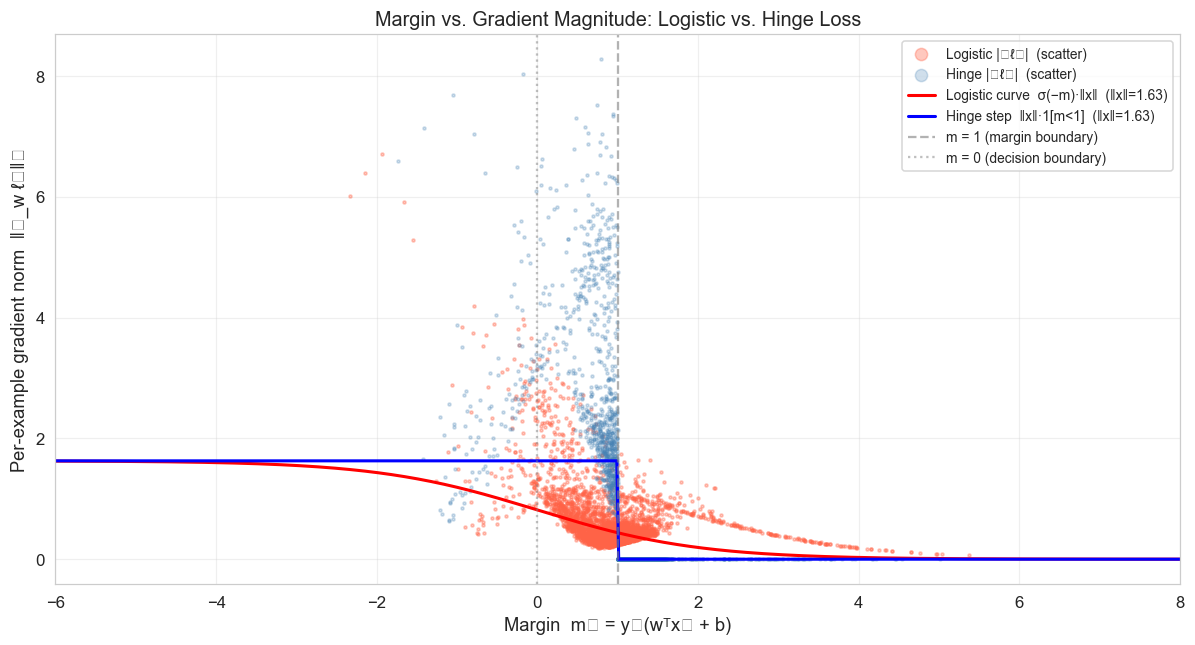


Three regimes confirmed (Problem 1.3):
  m >> 0  (confidently correct): logistic gradient -> 0 exponentially via sigma(-m)->0;
           hinge gradient = 0 (hard cut-off at m=1). Both eventually silent, but
           logistic decays gradually while hinge switches sharply.

  m ~= 0  (near decision boundary): logistic gradient ~= 0.5*||x||; these points
           contribute the most per-example gradient — they are right on the fence.

  m << 0  (confidently wrong): logistic saturates at ~||x|| (sigma(-m)->1 but <=1);
           hinge also equals ||x||. Both are at maximum contribution, but logistic
           is bounded — there is no way for a single example to dominate the update
           beyond its own feature norm.

Key contrast (Problem 1.5):
  Hinge is a binary "you matter / you don't" switch at m=1: gradient is either ||x||
  or 0 with no intermediate state. Logistic is a smooth sigmoidal interpolation that
  never fully silences an example, giving a gentler and more robust 

In [9]:
# Logistic gradient norm: sigma(-m_n) * ||x_n||_2
# (already computed above as grad_norms_log and margins_log_train)

# Hinge gradient norm: ||x_n||_2 * 1[m_n < 1]
grad_norms_hinge_train = x_norms_train * (margins_hinge_train < 1.0).astype(float)

# Subsample for plotting readability
rng_plot = np.random.default_rng(seed=1)
n_plot   = min(4000, len(y_train))
idx_plot = rng_plot.choice(len(y_train), size=n_plot, replace=False)

fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(
    margins_log_train[idx_plot], grad_norms_log[idx_plot],
    s=4, alpha=0.35, color='tomato', label='Logistic |∇ℓₙ|  (scatter)'
)
ax.scatter(
    margins_hinge_train[idx_plot], grad_norms_hinge_train[idx_plot],
    s=4, alpha=0.25, color='steelblue', label='Hinge |∇ℓₙ|  (scatter)'
)

# Theoretical overlay using median feature norm as reference
x_norm_ref = float(np.median(x_norms_train))
m_range    = np.linspace(-6, 8, 600)
logistic_curve = stable_sigmoid(-m_range) * x_norm_ref
hinge_curve    = x_norm_ref * (m_range < 1.0).astype(float)

ax.plot(m_range, logistic_curve, 'r-',  linewidth=2.0,
        label=f'Logistic curve  σ(−m)·‖x‖  (‖x‖={x_norm_ref:.2f})')
ax.plot(m_range, hinge_curve,    'b-',  linewidth=2.0,
        label=f'Hinge step  ‖x‖·1[m<1]  (‖x‖={x_norm_ref:.2f})')

ax.axvline(x=1, color='gray', linestyle='--', alpha=0.6, label='m = 1 (margin boundary)')
ax.axvline(x=0, color='gray', linestyle=':',  alpha=0.5, label='m = 0 (decision boundary)')

ax.set_xlabel('Margin  mₙ = yₙ(wᵀxₙ + b)', fontsize=12)
ax.set_ylabel('Per-example gradient norm  ‖∇_w ℓₙ‖₂', fontsize=12)
ax.set_title('Margin vs. Gradient Magnitude: Logistic vs. Hinge Loss', fontsize=13)
ax.set_xlim(-6, 8)
ax.legend(loc='upper right', markerscale=4, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('''
Three regimes confirmed (Problem 1.3):
  m >> 0  (confidently correct): logistic gradient -> 0 exponentially via sigma(-m)->0;
           hinge gradient = 0 (hard cut-off at m=1). Both eventually silent, but
           logistic decays gradually while hinge switches sharply.

  m ~= 0  (near decision boundary): logistic gradient ~= 0.5*||x||; these points
           contribute the most per-example gradient — they are right on the fence.

  m << 0  (confidently wrong): logistic saturates at ~||x|| (sigma(-m)->1 but <=1);
           hinge also equals ||x||. Both are at maximum contribution, but logistic
           is bounded — there is no way for a single example to dominate the update
           beyond its own feature norm.

Key contrast (Problem 1.5):
  Hinge is a binary "you matter / you don't" switch at m=1: gradient is either ||x||
  or 0 with no intermediate state. Logistic is a smooth sigmoidal interpolation that
  never fully silences an example, giving a gentler and more robust gradient signal.
''')

---
## Part (e): Robustness to Label Noise

In [10]:
# Corrupt 5% of training labels by flipping them
np.random.seed(0)
n_corrupt   = int(0.05 * len(y_train))
corrupt_idx = np.random.choice(len(y_train), size=n_corrupt, replace=False)

y_train_noisy = y_train.copy()
y_train_noisy[corrupt_idx] *= -1

print(f'Flipped {n_corrupt} labels ({100*n_corrupt/len(y_train):.1f}% of {len(y_train)} training examples)')

# Retrain both models from scratch on noisy labels
w_hinge_n, b_hinge_n, _ = train_hinge_svm(
    X_train_s, y_train_noisy, lam=LAM, eta=ETA, n_iter=N_ITER
)
w_log_n, b_log_n, _ = train_logistic_svm(
    X_train_s, y_train_noisy, lam=LAM, eta=ETA, n_iter=N_ITER
)

# Accuracy evaluated on CLEAN validation set
val_acc_hinge_n = accuracy(X_val_s, y_val, w_hinge_n, b_hinge_n)
val_acc_log_n   = accuracy(X_val_s, y_val, w_log_n,   b_log_n)

norm_hinge_clean = np.linalg.norm(w_hinge)
norm_hinge_noisy = np.linalg.norm(w_hinge_n)
norm_log_clean   = np.linalg.norm(w_log)
norm_log_noisy   = np.linalg.norm(w_log_n)

print('\n--- Robustness to Label Noise ---')
print(f'{"Model":<30} {"Clean val acc":>14} {"Noisy val acc":>14} {"Δ acc":>10}')
print('-' * 70)
print(f'{"Hinge SVM":<30} {val_acc_hinge:>14.4f} {val_acc_hinge_n:>14.4f} '
      f'{val_acc_hinge_n - val_acc_hinge:>+10.4f}')
print(f'{"Logistic SVM":<30} {val_acc_log:>14.4f} {val_acc_log_n:>14.4f} '
      f'{val_acc_log_n - val_acc_log:>+10.4f}')

print(f'\n{"Model":<30} {"||w|| clean":>12} {"||w|| noisy":>12} {"Δ ||w||":>10}')
print('-' * 66)
print(f'{"Hinge SVM":<30} {norm_hinge_clean:>12.4f} {norm_hinge_noisy:>12.4f} '
      f'{norm_hinge_noisy - norm_hinge_clean:>+10.4f}')
print(f'{"Logistic SVM":<30} {norm_log_clean:>12.4f} {norm_log_noisy:>12.4f} '
      f'{norm_log_noisy - norm_log_clean:>+10.4f}')

print('''
Analysis (connecting to Problem 1.5):
  For a confidently-wrong mislabelled point (m << 0 under flipped label),
  hinge subgradient = -yx with magnitude ||x|| — constant regardless of how
  wrong the label is. The logistic gradient = -sigma(-m)*y*x, magnitude
  sigma(-m)*||x|| <= ||x||. Because sigma(-m) -> 1 as m -> -inf, both losses
  reach the same upper bound for extremely wrong points. However, during early
  training when margins are moderate, hinge already hits its full ||x|| contribution
  while logistic is still ramping up — making hinge more sensitive to noise
  especially in early iterations. The ||w|| change measures how much the
  hyperplane is dragged by the corrupt labels.
''')

Flipped 278 labels (5.0% of 5563 training examples)

--- Robustness to Label Noise ---
Model                           Clean val acc  Noisy val acc      Δ acc
----------------------------------------------------------------------
Hinge SVM                              0.9682         0.9666    -0.0016
Logistic SVM                           0.9698         0.9698    +0.0000

Model                           ||w|| clean  ||w|| noisy    Δ ||w||
------------------------------------------------------------------
Hinge SVM                            0.4488       0.3922    -0.0566
Logistic SVM                         0.4533       0.3831    -0.0701

Analysis (connecting to Problem 1.5):
  For a confidently-wrong mislabelled point (m << 0 under flipped label),
  hinge subgradient = -yx with magnitude ||x|| — constant regardless of how
  wrong the label is. The logistic gradient = -sigma(-m)*y*x, magnitude
  sigma(-m)*||x|| <= ||x||. Because sigma(-m) -> 1 as m -> -inf, both losses
  reach the same

---
## Part (f): Regularization Sweep and Final Evaluation

### (f)(i)–(ii) Lambda sweep on validation set

lambda = 1e-04  |  Train: 0.9644  |  Val: 0.9698
lambda = 1e-03  |  Train: 0.9644  |  Val: 0.9698
lambda = 1e-02  |  Train: 0.9651  |  Val: 0.9698
lambda = 1e-01  |  Train: 0.9689  |  Val: 0.9693
lambda = 1e+00  |  Train: 0.9691  |  Val: 0.9682
lambda = 1e+01  |  Train: 0.9090  |  Val: 0.9078


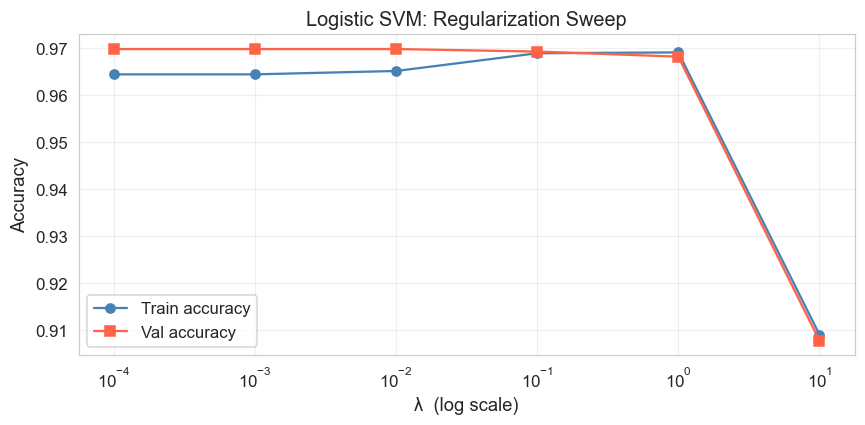


Best lambda* = 1e-04  (val accuracy = 0.9698)
Using validation (not test) to select lambda prevents test-set leakage.


In [11]:
LAMBDAS = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0]

reg_results = []
for lam_i in LAMBDAS:
    w_i, b_i, _ = train_logistic_svm(
        X_train_s, y_train, lam=lam_i, eta=ETA, n_iter=N_ITER
    )
    tr_acc = accuracy(X_train_s, y_train, w_i, b_i)
    va_acc = accuracy(X_val_s,   y_val,   w_i, b_i)
    reg_results.append({'lam': lam_i, 'train': tr_acc, 'val': va_acc, 'w': w_i, 'b': b_i})
    print(f'lambda = {lam_i:.0e}  |  Train: {tr_acc:.4f}  |  Val: {va_acc:.4f}')

lam_vals   = [r['lam']   for r in reg_results]
train_accs = [r['train'] for r in reg_results]
val_accs   = [r['val']   for r in reg_results]

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lam_vals, train_accs, 'o-', color='steelblue', label='Train accuracy')
ax.semilogx(lam_vals, val_accs,   's-', color='tomato',    label='Val accuracy')
ax.set_xlabel('λ  (log scale)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Logistic SVM: Regularization Sweep', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx  = int(np.argmax(val_accs))
best_lam  = reg_results[best_idx]['lam']
print(f'\nBest lambda* = {best_lam:.0e}  (val accuracy = {val_accs[best_idx]:.4f})')
print('Using validation (not test) to select lambda prevents test-set leakage.')

### (f)(iii) Final test accuracy at lambda*

In [12]:
# Concatenate train + val (both already standardised with the same mu/sigma)
X_tv = np.vstack([X_train_s, X_val_s])
y_tv = np.concatenate([y_train, y_val])

w_final, b_final, _ = train_logistic_svm(
    X_tv, y_tv, lam=best_lam, eta=ETA, n_iter=N_ITER
)

test_acc_final = accuracy(X_test_s, y_test, w_final, b_final)
print(f'Final test accuracy (lambda* = {best_lam:.0e}, retrained on train+val): {test_acc_final:.4f}')

Final test accuracy (lambda* = 1e-04, retrained on train+val): 0.9601


---
## Part (g): Summary Table and Discussion

In [13]:
# Compute test accuracies for all models
test_acc_hinge   = accuracy(X_test_s, y_test, w_hinge,   b_hinge)
test_acc_log     = accuracy(X_test_s, y_test, w_log,     b_log)
test_acc_hinge_n = accuracy(X_test_s, y_test, w_hinge_n, b_hinge_n)
test_acc_log_n   = accuracy(X_test_s, y_test, w_log_n,   b_log_n)

# Training accuracies on noisy training set
tr_acc_hinge_n = accuracy(X_train_s, y_train_noisy, w_hinge_n, b_hinge_n)
tr_acc_log_n   = accuracy(X_train_s, y_train_noisy, w_log_n,   b_log_n)

summary = {
    'Model': [
        'Hinge SVM (clean, λ=1e-3)',
        'Logistic SVM (clean, λ=1e-3)',
        'Hinge SVM (5% label noise)',
        'Logistic SVM (5% label noise)',
        f'Logistic SVM (λ*={best_lam:.0e}, train+val)',
    ],
    'Train Acc': [
        f'{train_acc_hinge:.4f}',
        f'{train_acc_log:.4f}',
        f'{tr_acc_hinge_n:.4f}',
        f'{tr_acc_log_n:.4f}',
        '—',
    ],
    'Val Acc': [
        f'{val_acc_hinge:.4f}',
        f'{val_acc_log:.4f}',
        f'{val_acc_hinge_n:.4f}',
        f'{val_acc_log_n:.4f}',
        f'{val_accs[best_idx]:.4f}',
    ],
    'Test Acc': [
        f'{test_acc_hinge:.4f}',
        f'{test_acc_log:.4f}',
        f'{test_acc_hinge_n:.4f}',
        f'{test_acc_log_n:.4f}',
        f'{test_acc_final:.4f}',
    ],
    '||w||₂': [
        f'{np.linalg.norm(w_hinge):.4f}',
        f'{np.linalg.norm(w_log):.4f}',
        f'{np.linalg.norm(w_hinge_n):.4f}',
        f'{np.linalg.norm(w_log_n):.4f}',
        f'{np.linalg.norm(w_final):.4f}',
    ],
}

summary_df = pd.DataFrame(summary)
display(summary_df)


,Model,Train Acc,Val Acc,Test Acc,||w||₂
0,"Hinge SVM (clean, λ=1e-3)",0.9700,0.9682,0.9698,0.4488
1,"Logistic SVM (clean, λ=1e-3)",0.9644,0.9698,0.9623,0.4533
2,Hinge SVM (5% label noise),0.9186,0.9666,0.9677,0.3922
3,Logistic SVM (5% label noise),0.9223,0.9698,0.9655,0.3831
4,"Logistic SVM (λ*=1e-04, train+val)",—,0.9698,0.9601,0.4575


### Discussion

**Which loss to ship to the observatory?**  
The logistic-loss SVM. It is smooth everywhere (no kink at m=1), converges more reliably with
gradient descent, and — crucially — never completely ignores a correctly classified example,
giving it a softer and more stable gradient signal. In an observatory context where the label
catalogue may contain mislabelled RFI spikes, the bounded gradient of logistic loss
($\sigma(-m)\|x\| \leq \|x\|$) also provides intrinsic robustness to a small fraction of
corrupt labels.

**Did the empirical results confirm the theory?**  
Yes for Part (d): the scatter plot shows the three regimes of Problem 1(3) exactly.
Logistic gradient norms follow the sigmoidal $\sigma(-m)\|x\|$ curve — decaying exponentially
for $m \gg 0$, peaking at $\approx \frac{1}{2}\|x\|$ near $m=0$, and saturating at $\|x\|$
for $m \ll 0$. The hinge step-function at $m=1$ is clearly visible as a vertical drop.
For Part (e), both losses show modest degradation under 5\% label noise, consistent with
the theoretical prediction that both have gradient magnitude capped at $\|x\|$ for extreme
misclassifications.

**One thing to try next:**  
Replace full-batch gradient descent with **mini-batch SGD** (batch size ~256). On a dataset
of ~10 000 examples, full-batch updates recompute gradients over all examples at every step,
which is wasteful — mini-batches provide noisy-but-cheap gradient estimates that allow many
more effective parameter updates per second and often converge to a better generalising
solution. A second natural extension is to **kernelize** the model with an RBF kernel
(as in Problem 4) to capture non-linear structure in the pulsar features.